## Modeling Overview – RUL Prediction
Train a **baseline Decision Tree** to quickly illustrate the data flow and evaluation metrics.

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib
import shap

### 1. Load Processed Data


In [2]:
filepath = "../data/processed/CMAPSSData/train_FD001_processed.csv"

df = pd.read_csv(filepath)

df.head()


,engine_id,cycle,op_setting_1,op_setting_2,s2,s3,s4,s6,s7,s8,...,s8_diff,s9_diff,s11_diff,s12_diff,s13_diff,s14_diff,s15_diff,s17_diff,s20_diff,s21_diff
0,1,6,-0.0043,-0.0001,642.10,1584.47,1398.37,21.61,554.67,2388.02,...,-0.04,-5.47,-0.12,-0.51,-0.01,-0.95,-0.0186,-2.0,0.08,-0.0375
1,1,7,0.0010,0.0001,642.48,1592.32,1397.77,21.61,554.34,2388.02,...,0.00,9.45,0.20,0.64,0.00,-0.53,-0.0134,1.0,0.12,0.0105
2,1,8,-0.0034,0.0003,642.56,1582.96,1400.97,21.61,553.85,2388.00,...,-0.02,-18.33,-0.12,0.15,0.00,-1.25,0.0102,-1.0,-0.13,-0.0668
3,1,9,0.0008,0.0001,642.12,1590.98,1394.80,21.61,553.69,2388.05,...,0.05,5.66,0.05,-0.68,0.02,-5.38,-0.0348,1.0,0.08,0.0960
4,1,10,-0.0033,0.0001,641.71,1591.24,1400.46,21.61,553.59,2388.05,...,0.00,5.24,-0.26,0.00,0.01,3.69,0.0558,1.0,-0.10,0.0628


To avoid data leakage, split by `engine_id`. Here randomly select 10% of engines for validation, this is a simplified version of the `GroupKFold` cross‑validation used in the main pipeline.

In [3]:
engine_ids = df['engine_id'].unique()

val_engine_ids = np.random.choice(engine_ids, size=int(0.1*len(engine_ids)))

df_train = df[~df['engine_id'].isin(val_engine_ids)]

df_val = df[df['engine_id'].isin(val_engine_ids)].copy()

In [4]:

X_train = df_train.drop(columns=["engine_id", "RUL", "will_fail_soon"] )
y_train = df_train["RUL"]

features = X_train.columns.to_list()
print(X_train.columns.to_list())

['cycle', 'op_setting_1', 'op_setting_2', 's2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21', 's2_roll_mean_5', 's2_roll_std_5', 's2_roll_mean_10', 's2_roll_std_10', 's2_roll_mean_30', 's2_roll_std_30', 's3_roll_mean_5', 's3_roll_std_5', 's3_roll_mean_10', 's3_roll_std_10', 's3_roll_mean_30', 's3_roll_std_30', 's4_roll_mean_5', 's4_roll_std_5', 's4_roll_mean_10', 's4_roll_std_10', 's4_roll_mean_30', 's4_roll_std_30', 's6_roll_mean_5', 's6_roll_std_5', 's6_roll_mean_10', 's6_roll_std_10', 's6_roll_mean_30', 's6_roll_std_30', 's7_roll_mean_5', 's7_roll_std_5', 's7_roll_mean_10', 's7_roll_std_10', 's7_roll_mean_30', 's7_roll_std_30', 's8_roll_mean_5', 's8_roll_std_5', 's8_roll_mean_10', 's8_roll_std_10', 's8_roll_mean_30', 's8_roll_std_30', 's9_roll_mean_5', 's9_roll_std_5', 's9_roll_mean_10', 's9_roll_std_10', 's9_roll_mean_30', 's9_roll_std_30', 's11_roll_mean_5', 's11_roll_std_5', 's11_roll_mean_10', 's11_roll_std_10', 's11_roll_mean_30', '

**Model training and saving locally**  
Simple decision tree with default parameters (This is not meant to be competitive; it only serves as a quick illustration)

In [5]:

decision_tree_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', DecisionTreeRegressor(random_state=42)) 
])

decision_tree_pipeline.fit(X_train, y_train)

joblib.dump(value=decision_tree_pipeline, filename="dt_model_pipeline.pkl")

['dt_model_pipeline.pkl']

In [6]:
trained_model_pipeline = joblib.load(filename="dt_model_pipeline.pkl")

Plot the tree structure to see which features are used for initial splits.

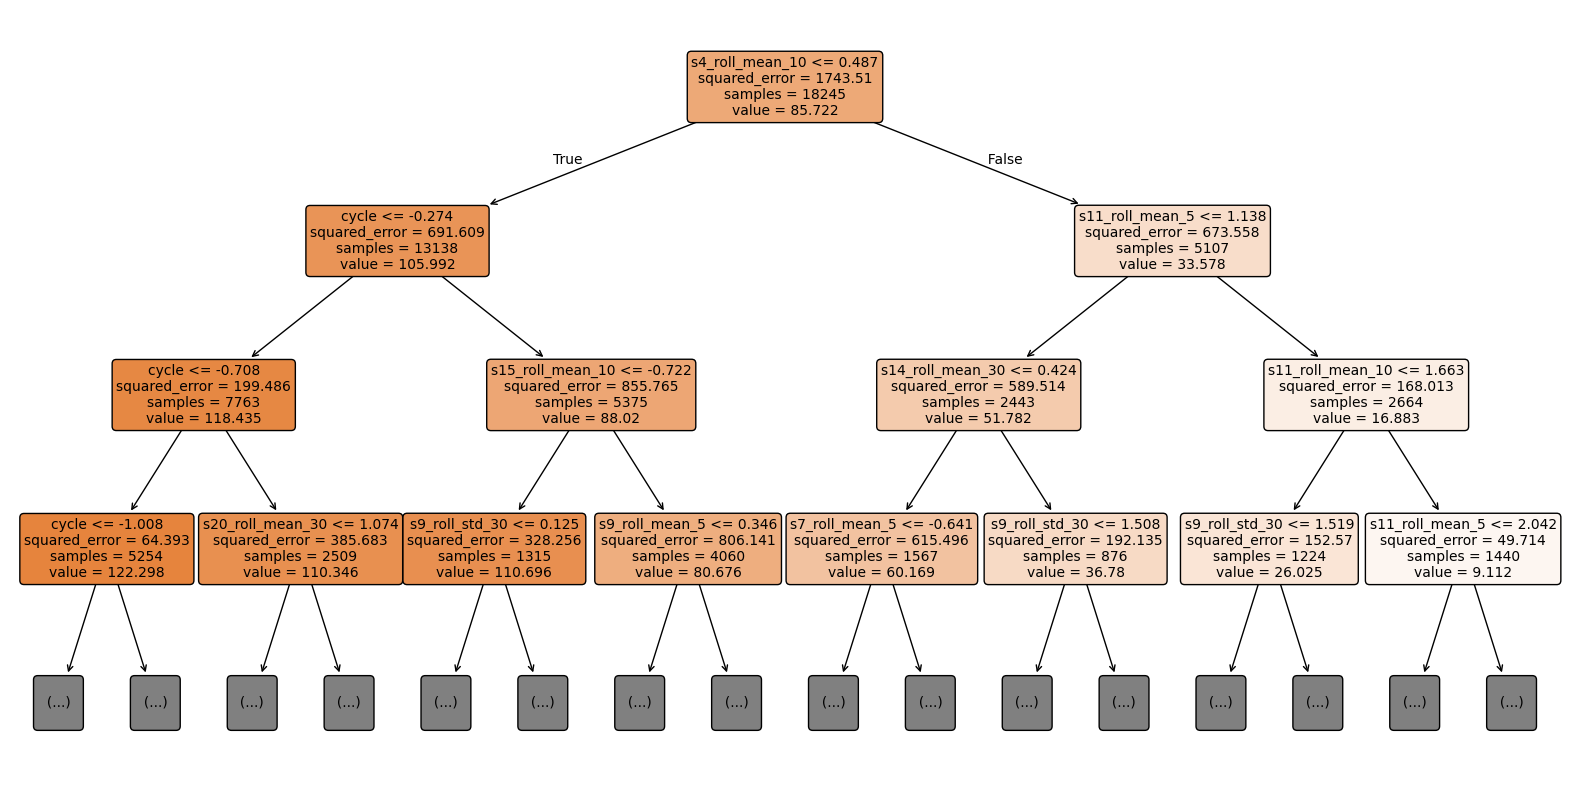

In [7]:
import matplotlib.pyplot as plt
from sklearn import tree


trained_model = trained_model_pipeline.named_steps['model']

plt.figure(figsize=(20,10))
tree.plot_tree(trained_model, feature_names=X_train.columns, max_depth=3,filled=True, rounded=True, fontsize=10)

plt.show()


In [8]:

X_val = df_val.drop(columns=["engine_id", "RUL", "will_fail_soon"] )
y_val = df_val["RUL"]

In [9]:
y_pred_dt = trained_model_pipeline.predict(X_val)


df_val['RUL_pred'] = y_pred_dt

df_val.head()

,engine_id,cycle,op_setting_1,op_setting_2,s2,s3,s4,s6,s7,s8,...,s9_diff,s11_diff,s12_diff,s13_diff,s14_diff,s15_diff,s17_diff,s20_diff,s21_diff,RUL_pred
4258,22,6,-0.0004,0.0003,642.66,1587.49,1413.09,21.61,553.75,2388.06,...,9.10,-0.30,0.33,-0.05,7.15,0.0168,-1.0,0.10,0.0692,110.0
4259,22,7,-0.0005,0.0002,642.63,1594.08,1406.14,21.61,553.59,2388.12,...,-4.73,0.25,-0.72,-0.02,-7.99,0.0217,1.0,0.13,-0.0476,110.0
4260,22,8,0.0011,-0.0004,643.18,1584.45,1418.91,21.61,553.83,2388.11,...,11.85,0.00,0.88,0.04,-1.41,-0.0254,-1.0,0.01,0.0216,110.0
4261,22,9,0.0009,-0.0005,643.11,1590.34,1409.79,21.61,553.57,2388.22,...,-11.47,-0.01,0.15,-0.01,-1.20,-0.0093,1.0,-0.10,-0.0301,125.0
4262,22,10,0.0012,-0.0003,642.29,1591.75,1411.62,21.61,553.33,2388.15,...,3.62,0.02,-0.38,-0.05,-2.01,0.0478,-1.0,-0.10,-0.0117,125.0


In [10]:
rul_df = pd.DataFrame({"cycle":df_val['cycle'],"rul_real":df_val["RUL"], "rul_pred":df_val['RUL_pred']}).reset_index(drop=True)
rul_df

,cycle,rul_real,rul_pred
0,6,125,110.0
1,7,125,110.0
2,8,125,110.0
3,9,125,125.0
4,10,125,125.0
...,...,...,...
1881,151,4,0.0
1882,152,3,5.0
1883,153,2,5.0
1884,154,1,0.0


### Evaluation Metrics
- **RMSE** – standard regression error.
- **NASA Score** (NASA asymmetric score) – penalises late predictions more heavily than early ones (Generally after heavy feature engineering its score somewhere below 350 on traditionla model like LightGBM).

In [11]:
def rmse(y_actual, y_pred):
    
    result = np.sqrt(np.mean((y_pred - y_actual)**2))
    
    return result

In [12]:
def nasa_score(y_actual, y_pred):

    diff = y_pred - y_actual
    score = np.where(diff < 0, np.exp(-diff / 13) - 1, np.exp(diff / 10) - 1)

    return np.sum(score)

In [13]:
rmse_val = rmse(y_actual=df_val['RUL'], y_pred=df_val['RUL_pred'])

nasa_score_val = nasa_score(y_actual=df_val['RUL'], y_pred=df_val['RUL_pred'])


print(f"Decision tree:\nRMSE:{rmse_val}, NASA score: {nasa_score_val}")

Decision tree:
RMSE:22.128684666010315, NASA score: 43571.07481445875


Visualizing predicted vs. actual RUL over the life cycle of 10 validation engines.

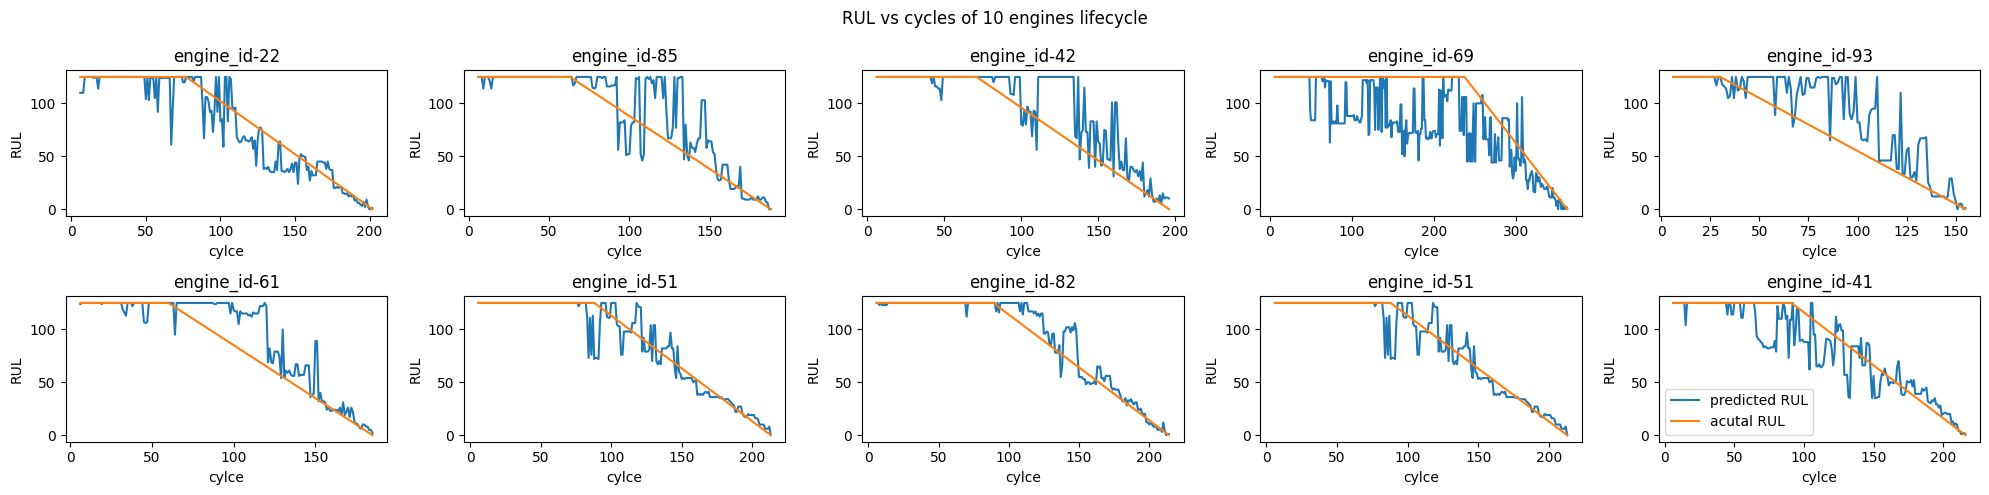

In [14]:
fig, axes = plt.subplots (nrows=2, ncols=5, figsize=(20, 5))
ax = axes.flatten()

val_engine_ids = val_engine_ids

for i, id in enumerate(val_engine_ids):
    
    df_id = df_val[df_val['engine_id']==id]

    ax[i].plot(df_id['cycle'], df_id['RUL_pred'], label='predicted RUL')
    ax[i].plot(df_id['cycle'], df_id['RUL'], label='acutal RUL')

    ax[i].set_xlabel('cylce')
    ax[i].set_ylabel('RUL')
    ax[i].set_title(f"engine_id-{id}")

plt.suptitle("RUL vs cycles of 10 engines lifecycle")
plt.tight_layout()
plt.legend()
plt.show()


 ### Predicted vs. Actual RUL (all validation points)
A scatter plot of predicted vs. actual RUL for every time step in the validation set.  
Points close to the red dashed line indicate accurate predictions.

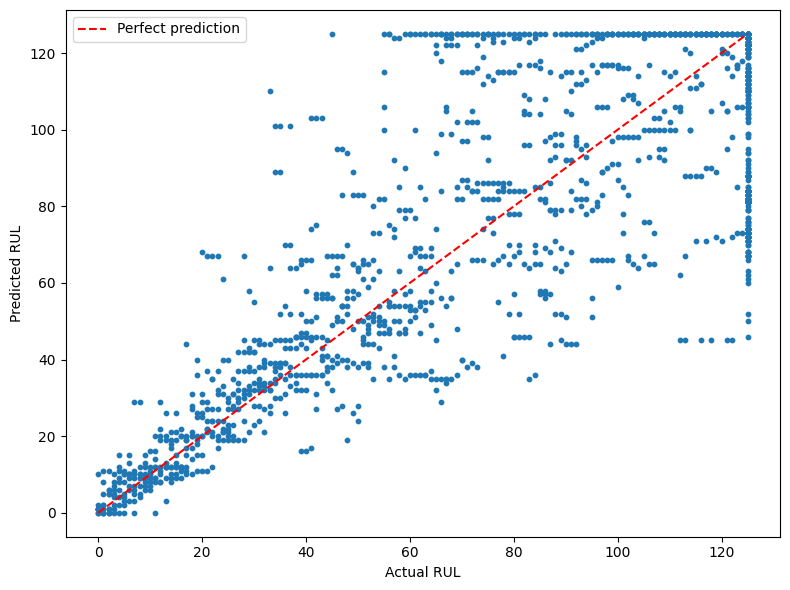

In [15]:
def plot_pred_vs_actual(y_pred, y_true):

    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, s=10)
    plt.plot([0, 125], [0, 125], "r--", label="Perfect prediction")
    plt.xlabel("Actual RUL")
    plt.ylabel("Predicted RUL") 
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_pred_vs_actual(df_val['RUL_pred'], df_val['RUL'])

### Model Interpretation with SHAP
To understand features and their importence visually

**Summary plot**  
*Shows the distribution of SHAP values for each feature across all data. Features are ordered by importance. Each point represents a single prediction; color indicates feature value (red high, blue low). It gives a global view of feature impact.*

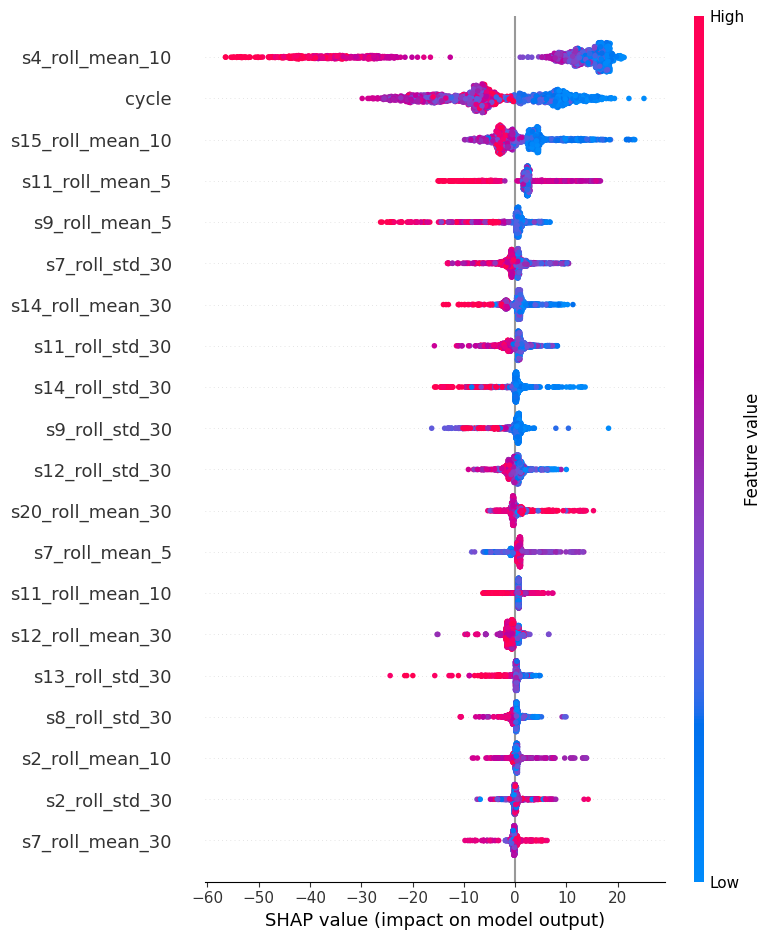

In [16]:
def shap_plot(model_pipeline, X, features):
    
    model = model_pipeline.named_steps['model']
    scaler = model_pipeline.named_steps['scaler']

    X = scaler.transform(X)
    
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
     
    shap.summary_plot(shap_values, X, feature_names=features, show=False)
    plt.tight_layout()
    plt.show() 
    plt.close() 

shap_plot(trained_model_pipeline, X_val, features)

**Summary plot (bar summary plot)**  
*A bar chart of mean absolute SHAP values per feature. Shows the global feature importance.*

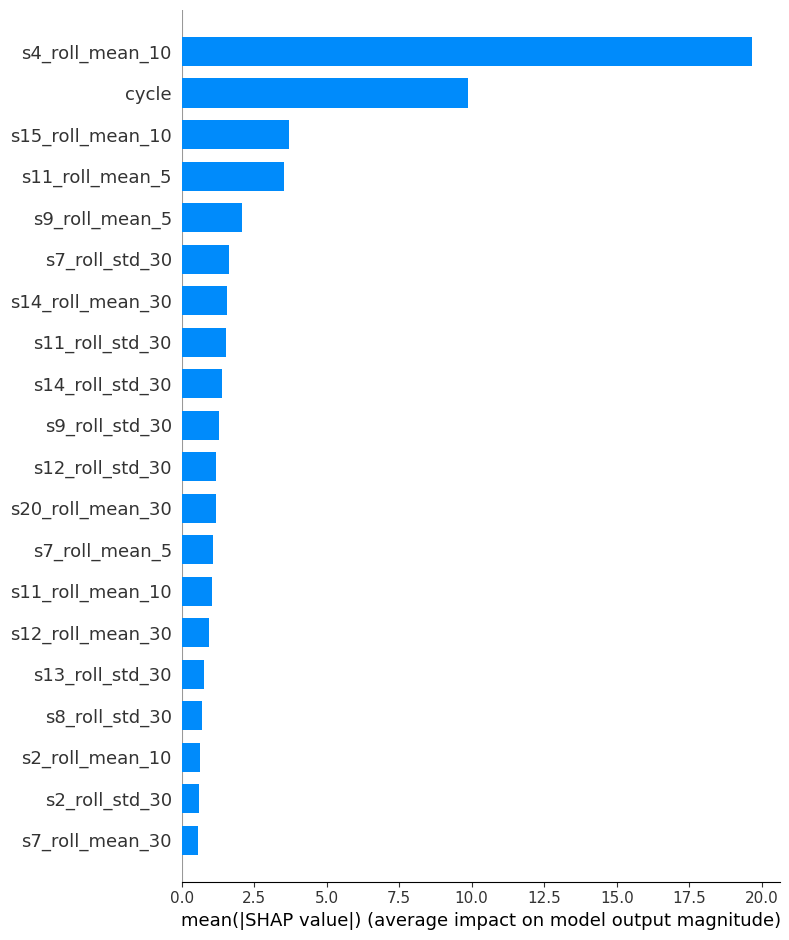

In [17]:
def shap_plot(model_pipeline, X, features):
    
    model = model_pipeline.named_steps['model']
    scaler = model_pipeline.named_steps['scaler']

    X = scaler.transform(X)
    
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    
    shap.summary_plot(shap_values, feature_names=features, plot_type="bar", show=False)
    plt.tight_layout()
    plt.show() 
    plt.close() 


shap_plot(trained_model_pipeline, X_val, features)

**Waterfall Plot**  
*Decomposes the prediction for a single instance (last row here) into contributions from each feature. It starts at the base value and adds/subtracts feature effects to arrive at the final prediction.*

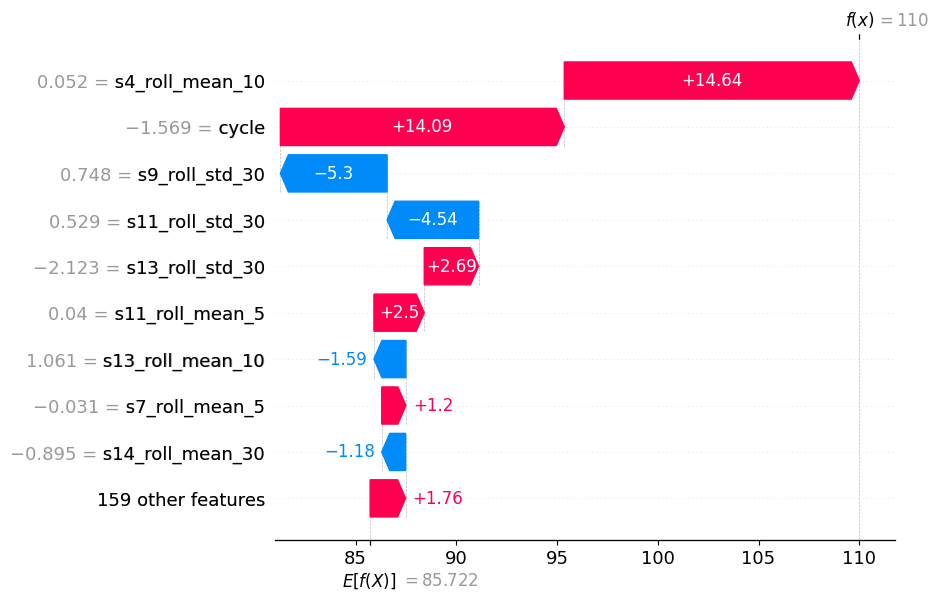

<Figure size 640x480 with 0 Axes>

In [18]:
def shap_plot(model_pipeline, X, features):
    
    model = model_pipeline.named_steps['model']
    scaler = model_pipeline.named_steps['scaler']

    X = scaler.transform(X)
    
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    
    shap.plots.waterfall(shap.Explanation(values=shap_values[0], base_values=explainer.expected_value, data=X[0], feature_names=features))
    plt.tight_layout()
    plt.show() 
    plt.close()


shap_plot(trained_model_pipeline, X_val, features)

**Force Plot**  
*Visualizes how each feature contributes to pushing the model output from the base value (expected prediction) to the final prediction for a single instance(last row of inputs). Features in red push the prediction higher, blue pushes it lower*.

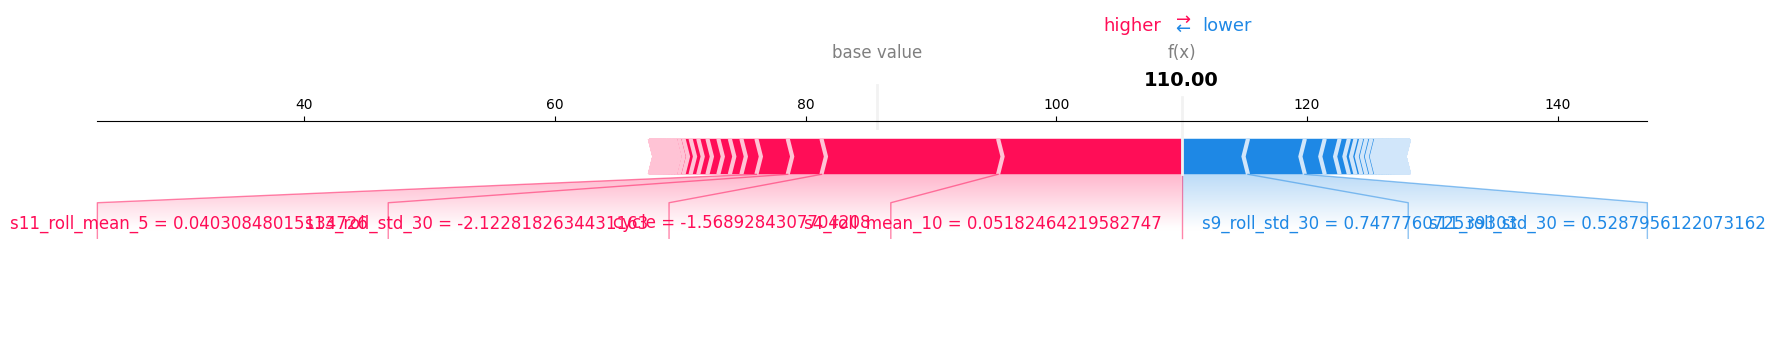

<Figure size 640x480 with 0 Axes>

In [19]:
def shap_plot(model_pipeline, X, features):
    
    model = model_pipeline.named_steps['model']
    scaler = model_pipeline.named_steps['scaler']

    X = scaler.transform(X)
    
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    
    shap.force_plot(base_value=explainer.expected_value, shap_values=shap_values[0], features=X[0], feature_names=features, matplotlib=True) 
    plt.tight_layout()
    plt.show() 
    plt.close()

shap_plot(trained_model_pipeline, X_val, features)

**SHAP Heatmap**  
*Displays the SHAP values of all features for every sample (here we use last 500 rows max) in a heatmap. Rows are features, columns are samples. It reveals patterns of feature impact across the dataset.*

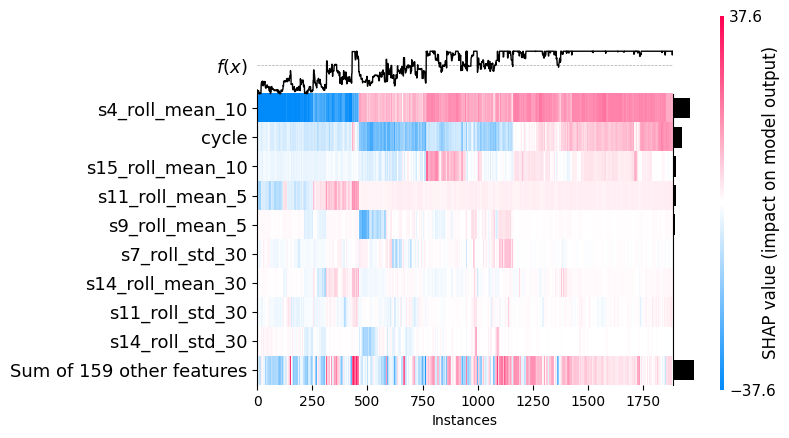

In [20]:
def shap_plot(model_pipeline, X, features):
    
    model = model_pipeline.named_steps['model']
    scaler = model_pipeline.named_steps['scaler']

    X = scaler.transform(X)
    

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    

    shap.plots.heatmap(shap.Explanation(values=shap_values, feature_names=features), show=False)
    plt.tight_layout()
    plt.show() 
    plt.close()


shap_plot(trained_model_pipeline, X_val, features)